Imports

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

Importing the dataset

In [83]:
df = pd.read_csv("dirty_cafe_sales.csv")

In [84]:
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,08/09/2023
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,16/05/2023
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,19/07/2023
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,27/04/2023
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,11/06/2023
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,31/03/2023
6,TXN_4433211,NaN,3.0,3.0,9.0,NaN,Takeaway,06/10/2023
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,NaN,28/10/2023
8,TXN_4717867,NaN,5.0,3.0,15.0,NaN,Takeaway,28/07/2023
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,31/12/2023


In [85]:
print (f"shape = The shape of the dataset is: {df.shape}")
print(                                                           )
print (f"columns = Name of columns in the dataset: {df.columns}")
print(                                                           )
print("dataset informtaion")
print (df.info)
print(                                                           )
print("dataset stats")
print(df.describe(include="all"))


shape = The shape of the dataset is: (10000, 8)

columns = Name of columns in the dataset: Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

dataset informtaion
<bound method DataFrame.info of      Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
2       TXN_4271903    Cookie       4.0             1.0          4.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
...             ...       ...       ...             ...          ...   
9995    TXN_7672686    Coffee       2.0             2.0          4.0   
9996    TXN_9659401       NaN       3.0             NaN          3.0   
9997    TXN_5255387    Coffee       4.0           

Data Preprocessing

In [86]:
#missing values

missing_values = print(df.isnull().sum())

Transaction ID         0
Item                 969
Quantity             474
Price Per Unit       532
Total Spent          499
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [87]:
#item count in item column

df["Item"].value_counts(dropna=False)

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
NaN          969
Name: count, dtype: int64

In [88]:
#item count in payment method column

df["Payment Method"].value_counts(dropna=False)

Payment Method
NaN               3178
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64

In [89]:
#item count in location column

df["Location"].value_counts(dropna=False)

Location
NaN         3961
Takeaway    3022
In-store    3017
Name: count, dtype: int64

In [90]:
#duplicate values 

duplicate = print(df.duplicated().sum())

0


In [91]:
#Looking for any unique values in the Item column

df["Item"].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', nan, 'Sandwich',
       'Juice', 'Tea'], dtype=object)

In [92]:
#Looking for any unique values in the Payment Method column

df["Payment Method"].unique()

array(['Credit Card', 'Cash', nan, 'Digital Wallet'], dtype=object)

In [93]:
#Looking for any unique values in the Location column

df["Location"].unique()

array(['Takeaway', 'In-store', nan], dtype=object)

In [94]:
#Checking the data type

data_type = print(f"The data type is: \n {(df.dtypes)}")

The data type is: 
 Transaction ID       object
Item                 object
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
dtype: object


Cleaning the dataset

In [95]:
#cleaning the text 

df["Item"] = df["Item"].str.strip().str.title()
df["Payment Method"] = df["Payment Method"].str.strip().str.title()
df["Location"] = df["Location"].str.strip().str.title()

In [96]:
#converting date to datetime format
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
df["Transaction Date"].isnull().sum()

np.int64(6258)

Handling missing values

In [97]:
df.loc[
    df["Total Spent"].isna() &
    df["Quantity"].notna() &
    df["Price Per Unit"].notna(),
    "Total Spent"
] = (
    df ["Quantity"] * df["Price Per Unit"]
)

In [98]:
df.loc[
    df["Price Per Unit"].isna() &
    df["Quantity"].notna() &
    df["Total Spent"].notna(),
    "Price Per Unit"
] = (
    df ["Total Spent"] / df["Quantity"]
)

In [99]:
df.loc[
    df["Quantity"].isna() &
    df["Total Spent"].notna() &
    df["Price Per Unit"].notna(),
    "Quantity"
] = (
    df ["Total Spent"] / df["Price Per Unit"]
)

In [100]:
#For missing values in item, payment method and location column

df["Item"] = df["Item"].fillna("Unknown")
df["Payment Method"] = df["Payment Method"].fillna("Unknown")
df["Location"] = df["Location"].fillna("Unknown")

In [101]:
print (f"The mean is {df["Total Spent"].mean()}")
print (f"The median is {df["Total Spent"].median()}")
print(f"The minimum is {df["Total Spent"].min()}")
print(f"The maximum is {df["Total Spent"].max()}")

The mean is 8.930923694779116
The median is 8.0
The minimum is 1.0
The maximum is 25.0


Insight: The average transaction value was 8.93 while the median was 8. Also, the minimum transaction value was 1 and the maximum was 25.

Data Validation

In [102]:
#Checking for null values 
df.isnull().sum()

Transaction ID         0
Item                   0
Quantity              38
Price Per Unit        38
Total Spent           40
Payment Method         0
Location               0
Transaction Date    6258
dtype: int64

In [103]:
#Checking for duplicate values (again)

df.duplicated().sum()

np.int64(0)

In [104]:
#Checking for data types

df.dtypes

Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

Saving the dataset

In [105]:
df.to_csv("cleaned_dataset.csv", index=False)

Exploratory Data Analysis

colors for charts

In [106]:
green_colors = ["#66c2a4", "#41ae76", "#238b45", "#005824" ]
purple_color = ["#8c96c6", "#8c6bb1", "#88419d", "#6e016b"]
blue_color = ["#08589e"]
orange_colors = ["#fdbb84", "#ef6548", "#990000"]


<Axes: title={'center': 'Which Product Sold the Most?'}, ylabel='Item'>

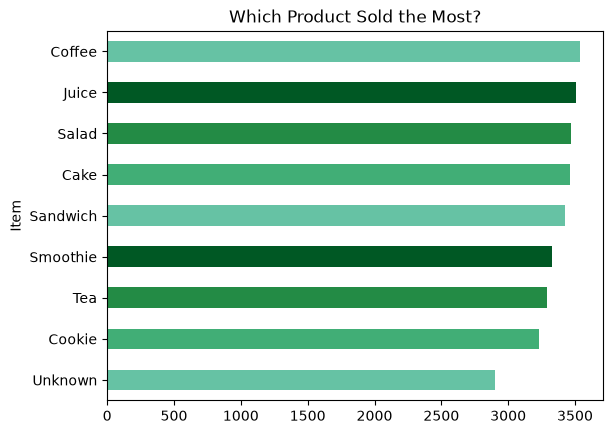

In [107]:
#Which product are sold the most?

df.groupby("Item")["Quantity"].sum().sort_values().plot(
    kind="barh", 
    color=green_colors,
    title= "Which Product Sold the Most?")

<Axes: title={'center': 'Which Product Generates the most Profit?'}, ylabel='Item'>

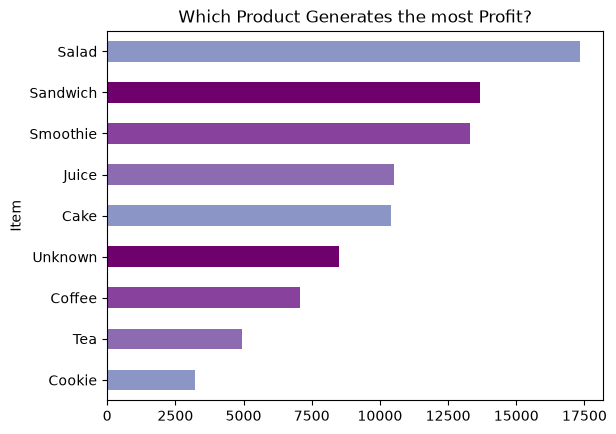

In [108]:
#Which product generates the most revenue?

df.groupby("Item")["Total Spent"].sum().sort_values().plot(
    kind="barh",
    color=purple_color,
    title= "Which Product Generates the most Profit?"
    )

In [109]:
#Which payment method was mostly used?

df.groupby("Payment Method")["Total Spent"].sum()


Payment Method
Cash              20366.5
Credit Card       20427.0
Digital Wallet    20383.5
Unknown           27775.0
Name: Total Spent, dtype: float64

<Axes: title={'center': 'Does Revenue Increase or Decrease Over Time?'}, xlabel='Month'>

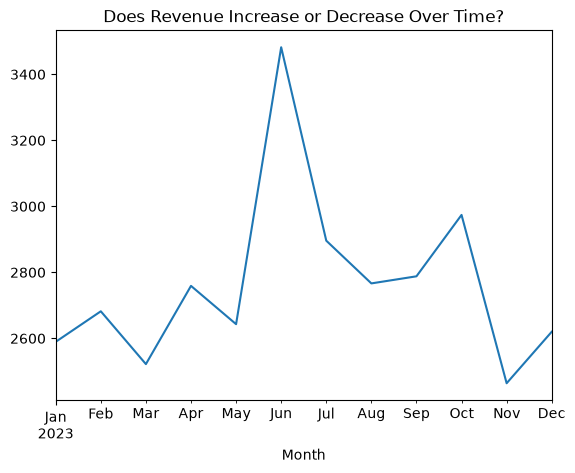

In [110]:
#Does profit increase/decrease over time?

df["Month"] = df["Transaction Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Total Spent"].sum()

monthly_sales.plot(
    kind="line",
    title="Does Revenue Increase or Decrease Over Time?")

In [111]:
#How are quantity, unit price, and total spending realted?

df[["Quantity", "Price Per Unit", "Total Spent"]].corr()

,Quantity,Price Per Unit,Total Spent
Quantity,1.000000,0.006825,0.704091
Price Per Unit,0.006825,1.000000,0.646687
Total Spent,0.704091,0.646687,1.000000


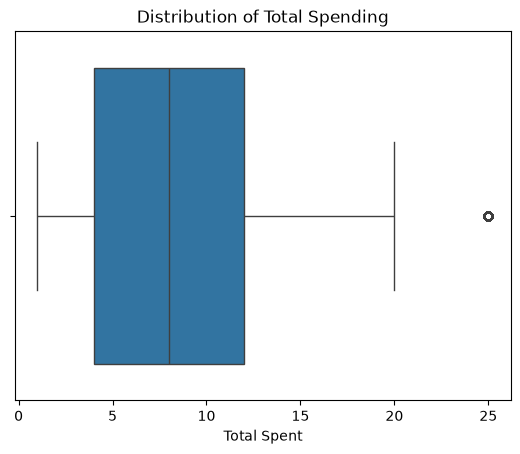

In [112]:
#Oulier Analysis 

#Total Spent

sns.boxplot(x=df["Total Spent"])
plt.title("Distribution of Total Spending")
plt.show()

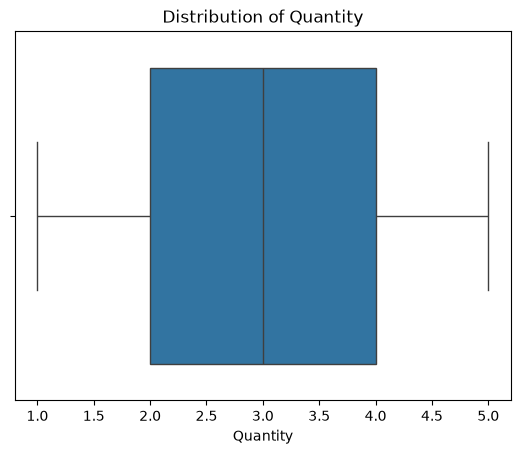

In [113]:
#Qunatity

sns.boxplot(x=df["Quantity"])
plt.title("Distribution of Quantity")
plt.show()

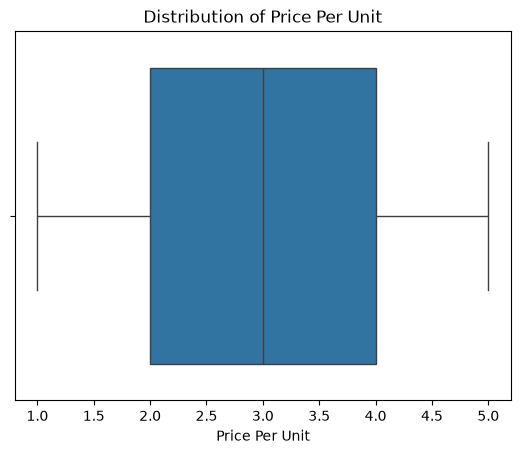

In [114]:
#Price Per Unit

sns.boxplot(x=df["Price Per Unit"])
plt.title("Distribution of Price Per Unit")
plt.show()

Data Visualization

<Axes: title={'center': 'Sales by Item'}, ylabel='Item'>

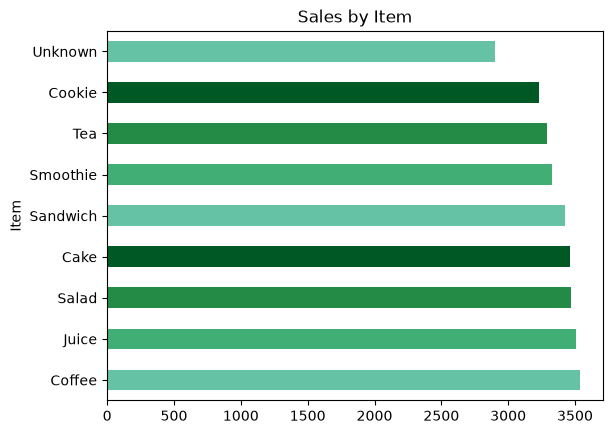

In [115]:
#Which cafe items are the most popular?

item_sales = df.groupby("Item")["Quantity"].sum().sort_values(ascending=False)

item_sales.plot(
    kind="barh",
    color=green_colors,
    title= "Sales by Item"
    )

Insight: The most frequently purchased product was Coffee and the least frequently purchased product was Cookie.

<Axes: title={'center': 'Profit by Item'}, xlabel='Item'>

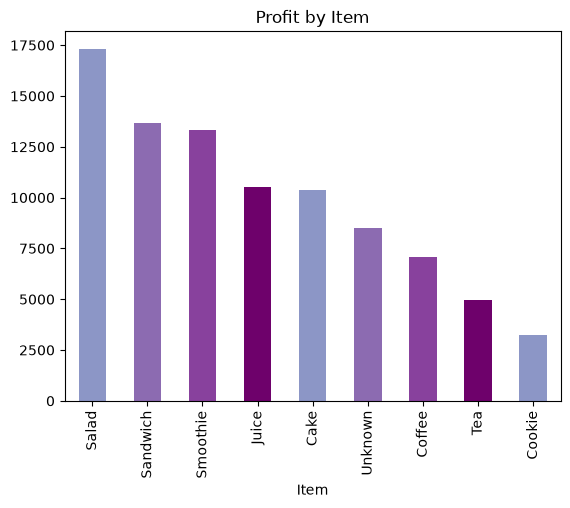

In [116]:
#Which produces the most profit?

item_revenue = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)

item_revenue.plot(
    kind="bar",
    color=purple_color,
    title="Profit by Item"
)

Insight: The product generating the highest profit was Salad and the product generating the lowest profit was Cookie. Although Coffee was sold the most, it was not able to generate much profit.

<Axes: title={'center': 'Monthly Profit'}, xlabel='Month'>

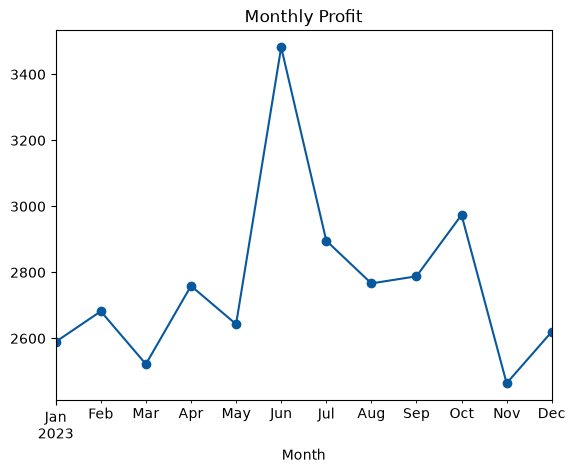

In [117]:
#How does profit change every month?

monthly_revenue = df.groupby("Month")["Total Spent"].sum()

monthly_revenue.plot(
    kind="line", 
    marker="o", 
    color=blue_color,
    title="Monthly Profit")

Insight: Profit peaked during June and dipped the most during November.

<Axes: title={'center': 'Payment Method'}, xlabel='Payment Method'>

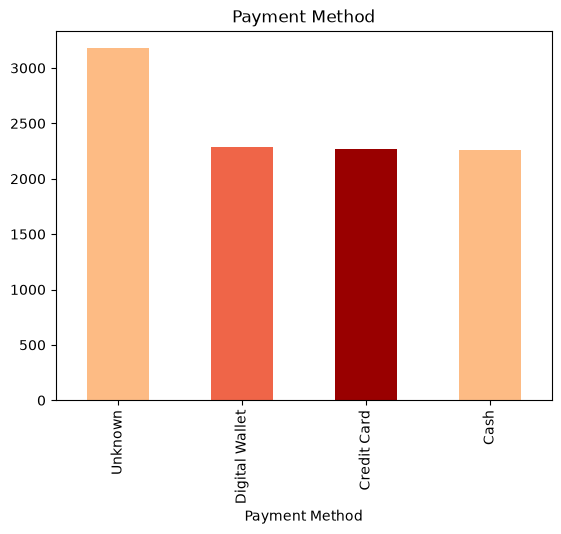

In [118]:
#Which payment methods do customers use most?

payment_counts = df["Payment Method"].value_counts()

payment_counts.plot(
    kind="bar",
    color=orange_colors,
    title="Payment Method"

)

Insight: Credit card was the most commonly used payment method, indicating that digital/card payments accounted for a significant share of customer transactions.

<Axes: title={'center': 'Quantity vs Total Spent'}, xlabel='Quantity', ylabel='Total Spent'>

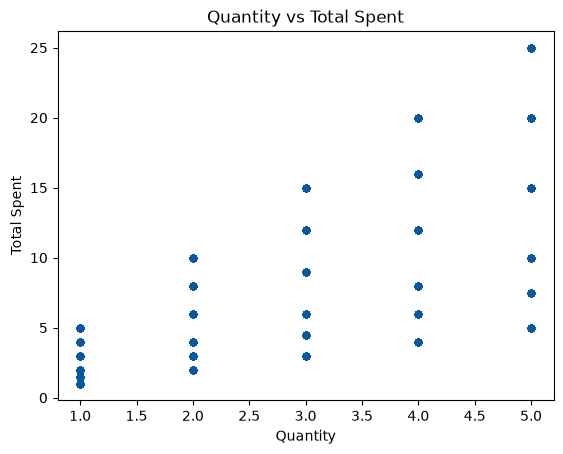

In [119]:
#Does buying more items generally lead to higher spending?

df.plot(
    x="Quantity",
    y="Total Spent",
    kind="scatter",
    color=blue_color,
    title="Quantity vs Total Spent"

)

Insight: Higher quantities were generally associated with higher total spending.

Limitations:

1. The dataset contains missing values in several key variables. Quantity has 38 missing values, Price Per Unit has 38 missing values, and Total Spent has 40 missing values.
2. Transaction Date contains 6,458 missing values, which limits the ability to perform complete time-based analysis.
3. Month also contains 6,458 missing values because it is derived from the Transaction Date field.
4. Monthly revenue analysis was therefore conducted only using transactions with an available Transaction Date. As a result, the monthly revenue trends may not represent the complete dataset.
5. Missing values and incomplete transaction information may affect the accuracy and completeness of some findings and should be considered when interpreting the results.


Recommendations:

1. Based on the sales analysis, the café could prioritize inventory for its highest-volume products.
2. Products generating high revenue could receive additional promotional attention.
3. The café could investigate periods with unusually low revenue to understand potential seasonal patterns.

Project Summary:

Objective: Analyze café transaction data to understand sales patterns, product performance, customer spending, and payment behavior.

Tools: Python, Pandas, Matplotlib, Seaborn

Process: Data Cleaning -> EDA -> Visualization -> Insights -> Recommendations

Outcome: A cleaned and analyzed dataset with visual insights into product sales, revenue, payment methods, spending behavior, and sales trends.